# VWAP skew / strangle — no fallback

Three-regime short-options strategy. When none fire, the strategy stays **flat**.

1. **spot ≥ VWAP + 20 bps** → skew: short PUT far (−3) + CALL near (+1), pyramided 1–2–3–4.
2. **spot ≤ VWAP − 20 bps** → mirror skew: CALL far (+3) + PUT near (−1).
3. **range < 15 bps** → tight strangle bracketing spot, all 10/side at once.
4. **else** → flat.

**Risk exits (skew & tight):** profit-take at 25% of credit · fixed stop at 40% loss · trailing (arms at 15%, give-back 15%) · time backstop.


In [ ]:
from engine import BirdsEye
from strategies.vwap_skew_strangle_nofallback import VwapSkewStrangleNoFallback

be = BirdsEye(
    data_dir          = "/mnt/INTERNAL_DATA/INTERN_DATA/OPRA_DATA_1SEC/0DTE/SPY",
    strategy_cls      = VwapSkewStrangleNoFallback,
    index             = "SPY",
    lot_size          = 100,
    starting_cash     = 1_000_000.0,
    margin_per_lot    = 10_000.0,
    fields            = ("spot", "atm_strike",
                         "ce_bid_0", "ce_ask_0", "pe_bid_0", "pe_ask_0",
                         "volume"),
    strategy_kwargs   = {
        "max_lots":         10,
        "lots":             10,
        "dev_bps_thresh":   20.0,       # |spot - VWAP| to trigger skew regime (bps)
        "range_bps_max":    15.0,       # trailing range ceiling for tight regime (bps)
        "range_win":        900,        # 15-min window for range alpha + warm-up
        "pyramid_schedule": (1, 2, 3, 4),
        "group_interval":   2 * 60,     # 2 min between pyramid groups
        "skew_max_hold":    2 * 60 * 60,
        "tight_hold":       2 * 60 * 60,
        "margin_per_lot":   10_000.0,   # must match BirdsEye margin_per_lot
        # --- per-trade risk exits (anchored to margin deployed) ---
        "profit_take_frac": 0.02,       # take profit at 2% of margin
        "stop_loss_frac":   0.01,       # cut at 1% of margin loss
        "trail_arm_frac":   0.015,      # trailing arms once up 1.5% of margin
        "trail_frac":       0.010,      # give back 1.0% of margin from peak
        # --- daily stop ---
        "day_stop_frac":    0.01,       # halt all new entries + exit open if day PnL <= -1% of total margin
        # --- VWAP ---
        "vwap_use_volume":      True,
        "volume_field":         "volume",
        "volume_is_cumulative": False,
        "quote_persist":        60,
    },
    cost_kwargs       = {"txn_cost_per_lot": 0.85},
    n_workers         = 40,
    collect_perseclog = True,
    # days=["20240102", "20240104"],
)
res = be.run()


In [2]:
import matplotlib.pyplot as plt

DAY = res.days[0]   # pick any day from the run

# 1. per-day summary
print("=== per-day summary ===")
display(res.summary)


=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,66,-311.0,168.0,-479.0
20240104,66,-213.5,192.5,-406.0
20240105,42,-197.5,143.9,-341.4
20240109,42,111.0,124.4,-13.4
20240110,66,12.0,182.0,-170.0
...,...,...,...,...
20250804,42,439.5,124.9,314.6
20250806,28,-493.5,55.1,-548.6
20250807,32,-1516.5,73.9,-1590.4


In [3]:
def display_stats(stats: dict):
    from IPython.display import display, HTML

    def fmt(k, v):
        if isinstance(v, float):
            if "pct" in k or "cagr" in k or "calmar" in k:
                color = "green" if v > 0 else "red"
                return f'<span style="color:{color}">{v:+.2f}%</span>'
            if "pnl" in k or "day" in k or "win" in k or "loss" in k or "cost" in k:
                color = "green" if v > 0 else ("red" if v < 0 else "inherit")
                return f'<span style="color:{color}">${v:+,.2f}</span>'
            return f"{v:.4f}"
        if isinstance(v, int):
            return f"{v:,}"
        return str(v)

    rows = "".join(
        f"<tr><td style='padding:4px 16px 4px 0;color:gray;font-size:13px'>{k}</td>"
        f"<td style='padding:4px 0;font-size:13px;font-weight:500'>{fmt(k,v)}</td></tr>"
        for k, v in stats.items()
    )
    display(HTML(f"<table style='border-collapse:collapse'>{rows}</table>"))

display_stats(res.stats())


n_days,277
total_pnl,"$-12,588.80"
avg_day,$-45.45
pct_pos_days,+0.54%
pct_neg_days,+0.46%
avg_win,$+504.33
avg_loss,$-685.43
best_day,"$+2,440.60"
worst_day,"$-2,155.00"
cagr_gross,+174.50%
maxDD_gross,89.3550


In [4]:
# trade ledger
led = res.tradelog
print(f"=== trade ledger: {len(led)} fills ===")
display(led.head(10))
print("\nfills by signal:")
display(led.groupby("signal")["exe_cost"].agg(["count","sum"]).round(2))


=== trade ledger: 12630 fills ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,...,alpha_c1_pe,alpha_c2_ce,alpha_c2_pe,alpha_t_ce,alpha_t_pe,alpha_c1_ok,alpha_c2_ok,alpha_t_ok,alpha_skew_legs_ok,alpha_tight_legs_ok
0,20240102,19:00:00,472.0,CE,SELL,1.0,0.74,0.85,0.0,0.5,...,468.0,474.0,470.0,472.0,471.0,1.0,1.0,1.0,1.0,1.0
1,20240102,19:00:00,471.0,PE,SELL,1.0,0.74,0.85,0.0,0.5,...,468.0,474.0,470.0,472.0,471.0,1.0,1.0,1.0,1.0,1.0
2,20240102,19:00:00,472.0,CE,SELL,2.0,0.76,1.70,0.0,1.0,...,469.0,475.0,471.0,472.0,471.0,1.0,1.0,1.0,1.0,1.0
3,20240102,19:00:00,471.0,PE,SELL,2.0,0.70,1.70,0.0,1.0,...,469.0,475.0,471.0,472.0,471.0,1.0,1.0,1.0,1.0,1.0
4,20240102,19:00:00,472.0,CE,SELL,3.0,0.84,2.55,0.0,1.5,...,469.0,475.0,471.0,472.0,471.0,1.0,1.0,1.0,1.0,1.0
5,20240102,19:00:00,471.0,PE,SELL,3.0,0.56,2.55,0.0,1.5,...,469.0,475.0,471.0,472.0,471.0,1.0,1.0,1.0,1.0,1.0
6,20240102,19:00:00,472.0,CE,SELL,4.0,1.04,3.40,0.0,2.0,...,469.0,475.0,471.0,473.0,472.0,1.0,1.0,1.0,1.0,1.0
7,20240102,19:00:00,471.0,PE,SELL,4.0,0.42,3.40,0.0,2.0,...,469.0,475.0,471.0,473.0,472.0,1.0,1.0,1.0,1.0,1.0
8,20240102,19:00:00,472.0,CE,BUY,1.0,1.31,0.85,0.0,1.0,...,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0,1.0
9,20240102,19:00:00,471.0,PE,BUY,1.0,0.12,0.85,0.0,0.5,...,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0,1.0



fills by signal:


,count,sum
signal,,
,402,4494.5
above_vwap,334,516.4
below_vwap,346,541.6
calm_range,854,1200.4
day_stop,238,608.8
skew_add,526,2101.7
skew_maxhold,1218,1961.8
stop_loss,206,599.1
tight_add,2504,10303.3


=== per-second log 20240102: 19769 rows ===


,timestamp,spot,atm,state,sec,vwap,dev_bps,range_bps,range_win_bps,day_stop_hit,...,c1_pe,c2_ce,c2_pe,t_ce,t_pe,c1_ok,c2_ok,t_ok,skew_legs_ok,tight_legs_ok
2000,2004,472.52,473.0,TIGHT_HOLD,2004.0,472.05,9.90,26.26,4.89,0.0,...,470.0,476.0,472.0,473.0,472.0,1.0,1.0,1.0,1.0,1.0
2001,2005,472.53,473.0,TIGHT_HOLD,2005.0,472.05,10.12,26.26,4.68,0.0,...,470.0,476.0,472.0,473.0,472.0,1.0,1.0,1.0,1.0,1.0
2002,2006,472.53,473.0,TIGHT_HOLD,2006.0,472.05,10.13,26.26,4.68,0.0,...,470.0,476.0,472.0,473.0,472.0,1.0,1.0,1.0,1.0,1.0
2003,2007,472.55,473.0,TIGHT_HOLD,2007.0,472.05,10.54,26.26,4.68,0.0,...,470.0,476.0,472.0,473.0,472.0,1.0,1.0,1.0,1.0,1.0
2004,2008,472.56,473.0,TIGHT_HOLD,2008.0,472.05,10.75,26.26,4.68,0.0,...,470.0,476.0,472.0,473.0,472.0,1.0,1.0,1.0,1.0,1.0


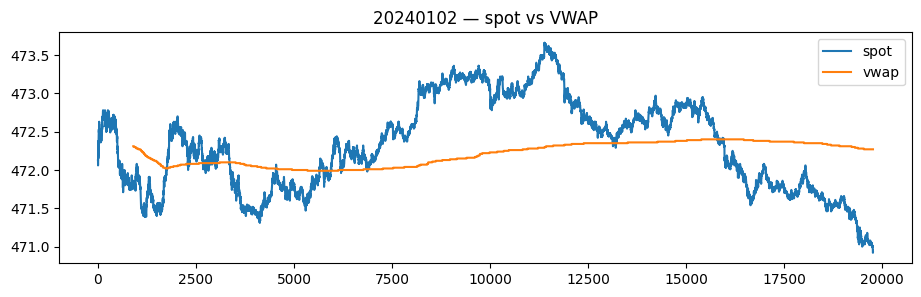

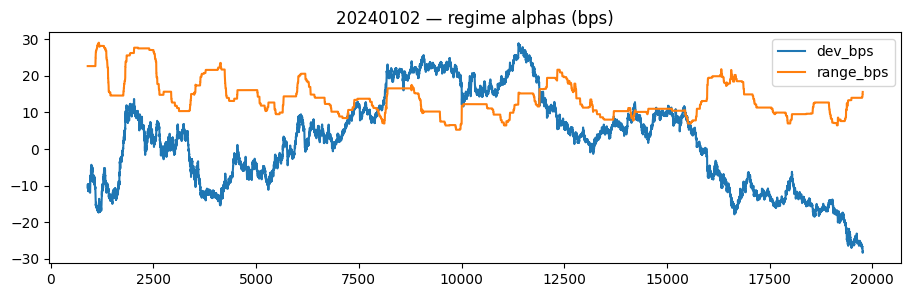

In [5]:
# per-second log for one day
sl = res.perseclog(DAY)
print(f"=== per-second log {DAY}: {len(sl)} rows ===")
display(sl.iloc[2000:2005])

import matplotlib.pyplot as plt
sl.plot(y=["spot","vwap"], figsize=(11,3), title=f"{DAY} — spot vs VWAP"); plt.show()
sl.plot(y=["dev_bps","range_bps"], figsize=(11,3), title=f"{DAY} — regime alphas (bps)"); plt.show()


array([<Axes: title={'center': 'net P&L (after costs)'}, ylabel='cum P&L ($)'>,
       <Axes: title={'center': 'mid-only P&L (no costs)'}, xlabel='days', ylabel='cum P&L ($)'>],
      dtype=object)

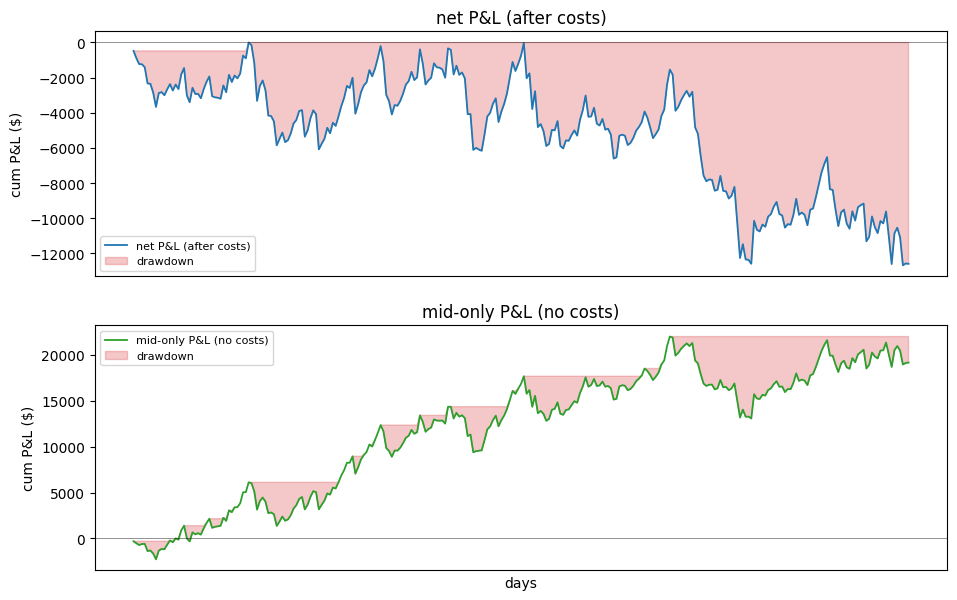

In [6]:
from engine.plots import plot_equity
plot_equity(res)


In [7]:
# ============================================================================
# PnL statistics by TRADE TYPE (one episode = one round trip)
#   skew  : above_vwap / below_vwap  +  skew_add(s)  +  stop (profit_take/stop_loss/trailing/skew_maxhold/day_stop)
#   tight : calm_range  +  tight_add(s)  +  stop (profit_take/stop_loss/trailing/tight_done/day_stop)
# mid-p PnL uses ONLY fill prices (SELL = +price, BUY = -price) x lots x lot_size.
# t-cost is the ledger's exe_cost (txn + brokerage + spread).
# ============================================================================
import numpy as np
import pandas as pd

_OPENERS = {"above_vwap": "skew", "below_vwap": "skew", "calm_range": "tight"}
_ADDERS  = {"skew_add": "skew", "tight_add": "tight"}
_CLOSERS = {"profit_take": "skew", "stop_loss": "skew", "trailing": "skew",
            "skew_maxhold": "skew",
            "tight_done": "tight"}


def _segment(df):
    df   = df.reset_index(drop=True)
    sigs = df["signal"].tolist()
    runs, start = [], 0
    for k in range(1, len(df) + 1):
        if k == len(df) or sigs[k] != sigs[start]:
            runs.append(df.iloc[start:k]); start = k

    eps, cur = [], None
    for run in runs:
        sig = run["signal"].iloc[0]
        if sig in _OPENERS:
            if cur is not None: eps.append(cur)
            cur = {"type": _OPENERS[sig], "fills": [run]}
        elif cur is not None:
            cur["fills"].append(run)
            if sig in _CLOSERS or sig in ("eod_square_off", "day_stop"):
                eps.append(cur); cur = None
        else:
            t = _ADDERS.get(sig) or _CLOSERS.get(sig) or "unknown"
            cur = {"type": t, "fills": [run]}
            if sig in _CLOSERS or sig in ("eod_square_off", "day_stop"):
                eps.append(cur); cur = None
    if cur is not None: eps.append(cur)
    for e in eps: e["fills"] = pd.concat(e["fills"], ignore_index=True)
    return eps


def _episode_stats(ep, lot_size):
    f      = ep["fills"]
    sign   = np.where(f["action"] == "SELL", 1.0, -1.0)
    midp   = float((sign * f["fill_price"] * f["lots"] * lot_size).sum())
    tcost  = float(f["exe_cost"].sum())
    openl  = float(f.loc[f["action"] == "SELL", "lots"].sum())
    net_pos= float(np.where(f["action"] == "BUY", f["lots"], -f["lots"]).sum())
    return {"type": ep["type"], "n_fills": len(f), "midp_pnl": midp, "tcost": tcost,
            "net_pnl": midp - tcost, "open_lots": openl, "flat": abs(net_pos) < 1e-9}


def trade_pnl_stats(led, lot_size, verbose=True):
    """Per-trade-type PnL stats. Returns (per_type_table, per_trade_table)."""
    if led is None or len(led) == 0:
        if verbose: print("empty ledger"); return pd.DataFrame(), pd.DataFrame()
    eps = []
    for _, g in led.groupby("day", sort=True):
        eps += _segment(g)
    per_trade = pd.DataFrame([_episode_stats(e, lot_size) for e in eps])
    order = ["skew", "tight"]
    agg = per_trade.groupby("type").agg(
        trades=("type","size"), midp_pnl=("midp_pnl","sum"),
        tcost=("tcost","sum"), net_pnl=("net_pnl","sum"), open_lots=("open_lots","sum"))
    agg = agg.reindex([t for t in order if t in agg.index]
                      + [t for t in agg.index if t not in order])
    agg["midp_per_lot"]   = agg["midp_pnl"] / agg["open_lots"].replace(0, np.nan)
    agg["midp_per_trade"] = agg["midp_pnl"] / agg["trades"]
    agg["tcost_per_trade"]= agg["tcost"]    / agg["trades"]
    total = pd.Series({
        "trades": agg["trades"].sum(), "midp_pnl": agg["midp_pnl"].sum(),
        "tcost": agg["tcost"].sum(), "net_pnl": agg["net_pnl"].sum(),
        "open_lots": agg["open_lots"].sum(),
        "midp_per_lot":    agg["midp_pnl"].sum() / max(agg["open_lots"].sum(), 1e-9),
        "midp_per_trade":  agg["midp_pnl"].sum() / max(agg["trades"].sum(), 1),
        "tcost_per_trade": agg["tcost"].sum()    / max(agg["trades"].sum(), 1),
    }, name="TOTAL")
    table = pd.concat([agg, total.to_frame().T])
    if verbose:
        show = table.copy()
        for c in ["midp_pnl","tcost","net_pnl","midp_per_lot","midp_per_trade","tcost_per_trade"]:
            show[c] = show[c].astype(float).round(2)
        show["trades"]    = show["trades"].astype(int)
        show["open_lots"] = show["open_lots"].astype(float).round(0).astype(int)
        print("=== PnL by trade type (mid-price) ==="); print(show.to_string())
        n_open = int((~per_trade["flat"]).sum())
        if n_open: print(f"\nNote: {n_open} episode(s) not flat.")
        print(f"\nTOTAL NET PnL (after costs):     {table.loc['TOTAL','net_pnl']:,.2f}")
        print(f"TOTAL mid-p PnL (before costs):  {table.loc['TOTAL','midp_pnl']:,.2f}")
        print(f"TOTAL t-costs:                   {table.loc['TOTAL','tcost']:,.2f}")
        print(f"mid-p PnL per opening lot:       {table.loc['TOTAL','midp_per_lot']:,.4f}")
    return table, per_trade


pnl_by_type, pnl_by_trade = trade_pnl_stats(res.tradelog, lot_size=res.cfg.lot_size)


=== PnL by trade type (mid-price) ===
       trades  midp_pnl    tcost  net_pnl  open_lots  midp_per_lot  midp_per_trade  tcost_per_trade
skew      340   -1824.0   6637.9  -8461.9       2012         -0.91           -5.36            19.52
tight     427   20631.0  25132.4  -4501.4       8342          2.47           48.32            58.86
TOTAL     767   18807.0  31770.3 -12963.3      10354          1.82           24.52            41.42

TOTAL NET PnL (after costs):     -12,963.30
TOTAL mid-p PnL (before costs):  18,807.00
TOTAL t-costs:                   31,770.30
mid-p PnL per opening lot:       1.8164


In [8]:
import pandas as pd
import numpy as np

def time_in_market_stats(res, verbose=True):
    """
    Compute time-in-market statistics from the per-second log.
    
    'In market' = any state except WAIT and EXECUTING.
    Returns a per-day DataFrame and a summary dict.
    """
    OUT_OF_MARKET = {"WAIT", "EXECUTING"}
    rows = []

    for day in res.days:
        try:
            sl = res.perseclog(day)
        except ValueError:
            continue  # day has no perseclog (collect_perseclog was False)

        total    = len(sl)
        in_mkt   = (~sl["state"].isin(OUT_OF_MARKET)).sum()
        pct      = 100.0 * in_mkt / total if total else 0.0

        # time per regime
        skew_secs  = sl["state"].isin({"SKEW_ADD", "SKEW_HOLD", "SKEW_FROZEN"}).sum()
        tight_secs = sl["state"].isin({"TIGHT_ADD", "TIGHT_HOLD", "TIGHT_FROZEN"}).sum()

        # number of distinct episodes (transitions into a non-WAIT state from WAIT)
        states = sl["state"].tolist()
        episodes = sum(
            1 for i in range(1, len(states))
            if states[i] not in OUT_OF_MARKET and states[i-1] in OUT_OF_MARKET
        )

        rows.append({
            "day":           day,
            "total_secs":    total,
            "in_mkt_secs":   int(in_mkt),
            "in_mkt_pct":    round(pct, 1),
            "skew_secs":     int(skew_secs),
            "tight_secs":    int(tight_secs),
            "episodes":      episodes,
            "avg_hold_secs": round(in_mkt / episodes, 1) if episodes else 0.0,
        })

    df = pd.DataFrame(rows).set_index("day")

    summary = {
        "days_run":           len(df),
        "avg_in_mkt_pct":     round(df["in_mkt_pct"].mean(), 1),
        "median_in_mkt_pct":  round(df["in_mkt_pct"].median(), 1),
        "min_in_mkt_pct":     round(df["in_mkt_pct"].min(), 1),
        "max_in_mkt_pct":     round(df["in_mkt_pct"].max(), 1),
        "avg_skew_secs":      round(df["skew_secs"].mean(), 1),
        "avg_tight_secs":     round(df["tight_secs"].mean(), 1),
        "avg_episodes":       round(df["episodes"].mean(), 1),
        "avg_hold_secs":      round(df["avg_hold_secs"].mean(), 1),
        "avg_hold_mins":      round(df["avg_hold_secs"].mean() / 60, 1),
    }

    if verbose:
        print("=== Time in market ===")
        display(df)
        print()
        for k, v in summary.items():
            print(f"  {k:<22}: {v}")

    return df, summary


tim_df, tim_summary = time_in_market_stats(res)

=== Time in market ===


,total_secs,in_mkt_secs,in_mkt_pct,skew_secs,tight_secs,episodes,avg_hold_secs
day,,,,,,,
20240102,19769,18314,92.6,7196,11118,3,6104.7
20240104,19769,18767,94.9,0,18767,3,6255.7
20240105,19781,18047,91.2,0,18047,3,6015.7
20240109,19781,18878,95.4,7199,11679,3,6292.7
20240110,19769,18747,94.8,0,18747,3,6249.0
...,...,...,...,...,...,...,...
20250804,19781,18763,94.9,7199,11564,3,6254.3
20250806,19787,14395,72.7,14395,0,2,7197.5
20250807,19785,14395,72.8,14395,0,2,7197.5



  days_run              : 277
  avg_in_mkt_pct        : 87.8
  median_in_mkt_pct     : 93.6
  min_in_mkt_pct        : 12.4
  max_in_mkt_pct        : 95.4
  avg_skew_secs         : 7412.5
  avg_tight_secs        : 9874.5
  avg_episodes          : 2.8
  avg_hold_secs         : 6295.4
  avg_hold_mins         : 104.9
